In [17]:
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import numpy as np
import pandas as pd
from Functional_Fusion import atlas_map as am
import nitools as nt
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
from itertools import combinations
from itertools import combinations_with_replacement
from matplotlib.colors import LinearSegmentedColormap
import random
import seaborn as sns
import nilearn.plotting as plotting
from nilearn import datasets
from matplotlib.backends.backend_pdf import PdfPages
import Functional_Fusion.atlas_map as am
import plotly.io as pio


In [2]:
colors = ["#62c4ff", "#3a93f7", "#1e6bf9",'#1244d7','#e55b2d','#e86c22','#f8d24d','#f3f36d']
custom_cmap = LinearSegmentedColormap.from_list("custom_colormap", colors)
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'

# Define ROI

In [3]:
ROI_labels = [6,7]

In [4]:
atlas, _ = am.get_atlas('fs32k')

atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/yeo7.L.label.gii'
model_name_R = f'{atlas_dir}/yeo7.R.label.gii'

yeo_parcels = atlas.read_data([model_name_L,model_name_R])
yeo_parcels_binary = np.isin(yeo_parcels, ROI_labels).astype(int)


# Load data

In [5]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb,info_mdtb  =MDTB_dataset.get_data(space='fs32k',ses_id='ses-s1',type='CondAll')
data_mdtb =np.nanmean(data_mdtb,axis =0)


In [6]:
info_mdtb.cond_name

0                  NoGo
1                    Go
2                   ToM
3              VideoAct
4            VideoKnots
5      UnpleasantScenes
6        PleasantScenes
7                  Math
8        DigitJudgement
9          CheckerBoard
10             SadFaces
11           HappyFaces
12       IntervalTiming
13         MotorImagery
14         FingerSimple
15            FingerSeq
16          Verbal0Back
17          Verbal2Back
18          Object0Back
19          Object2Back
20    SpatialNavigation
21          StroopIncon
22            StroopCon
23              VerbGen
24             WordRead
25    VisualSearchSmall
26      VisualSearchMed
27    VisualSearchLarge
28                 rest
Name: cond_name, dtype: object

In [7]:
Language_dataset = DataSetLanguage(f'{base_dir}/Language')
data_language,info_language  =Language_dataset.get_data(space='fs32k',ses_id='ses-localizer_cond',type='CondAll')
info_language['taskName'] = info_language['taskName'].str.strip()
data_language =np.nanmean(data_language,axis =0)
mean_across_conds = np.nanmean(data_language,axis =0)
data_language = data_language - mean_across_conds


In [8]:
data_language.shape

(18, 59518)

In [9]:
info_language.taskName

0                          rest
1                  word_reading
2               verb_GENERATION
3     action_observation_action
4            action_observation
5                intact_passage
6              degraded_passage
7               tongue_movement
8               finger_sequence
9                theory_of_mind
10           auditory_narrative
11                       n_back
12                      oddball
13                  demand_grid
14                romance_movie
15           spatial_navigation
16             sentence_reading
17              nonword_reading
Name: taskName, dtype: object

In [10]:
shared_conditions =[('theory_of_mind','ToM'),('rest','rest'),('finger_sequence','FingerSeq'),('action_observation_action','VideoAct'),('action_observation','VideoKnots'),('verb_GENERATION','VerbGen'),('word_reading','WordRead'),('spatial_navigation','SpatialNavigation')]

In [11]:
shared_conditions

[('theory_of_mind', 'ToM'),
 ('rest', 'rest'),
 ('finger_sequence', 'FingerSeq'),
 ('action_observation_action', 'VideoAct'),
 ('action_observation', 'VideoKnots'),
 ('verb_GENERATION', 'VerbGen'),
 ('word_reading', 'WordRead'),
 ('spatial_navigation', 'SpatialNavigation')]

# Align each dataset to mean of shared then average shared, stack all conds and align to mean of all tasks

In [12]:
# Subtract mean of shared conditions (more stable?)
shared_indices = []
for cond_pair in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == cond_pair[1]].index
    shared_indices.append(mdtb_index)
data_mdtb_vshared = data_mdtb - np.nanmean(data_mdtb[shared_indices,:].squeeze(),axis=0)
print(data_mdtb_vshared.shape)


shared_indices = []
for cond_pair in shared_conditions:
    language_index = info_language[info_language['taskName'] == cond_pair[0]].index
    shared_indices.append(language_index)
data_language_vshared = data_language - np.nanmean(data_language[shared_indices,:].squeeze(),axis=0)
print(data_language_vshared.shape)

(29, 59518)
(18, 59518)


In [13]:
# Average shared conds and add novel conds
shared_data = []
shared_labels = []

for lang_cond, mdtb_cond in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == mdtb_cond].index
    lang_index = info_language[info_language['taskName'] == lang_cond].index
    
    if not mdtb_index.empty and not lang_index.empty:
        mdtb_cond_data = data_mdtb_vshared[mdtb_index, :].squeeze()
        lang_cond_data = data_language_vshared[lang_index, :].squeeze()
        
        # average shared
        avg_data = (mdtb_cond_data + lang_cond_data) / 2
        shared_data.append(avg_data)
        shared_labels.append(mdtb_cond)  # use mdtb cond names for shared conds

# Convert to np
shared_data = np.array(shared_data)

# Extract novel tasks from each dataset, excluding shared tasks
novel_data_mdtb = data_mdtb_vshared[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions]), :]
novel_data_language = data_language_vshared[~info_language['taskName'].isin([cond[0] for cond in shared_conditions]), :]

# Combine shared data with novel data
combined_data_v2 = np.vstack([shared_data, novel_data_mdtb, novel_data_language])

# Combine labels for shared and novel data
combined_labels = shared_labels + \
                  info_mdtb[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions])]['cond_name'].tolist() + \
                  info_language[~info_language['taskName'].isin([cond[0] for cond in shared_conditions])]['taskName'].tolist()

# Create new info df
new_info_v2 = pd.DataFrame({
    'taskName': combined_labels,
    'source': ['shared']*len(shared_labels) + ['mdtb']*novel_data_mdtb.shape[0] + ['language']*novel_data_language.shape[0]
})

combined_data_v2.shape,new_info_v2


((39, 59518),
               taskName    source
 0                  ToM    shared
 1                 rest    shared
 2            FingerSeq    shared
 3             VideoAct    shared
 4           VideoKnots    shared
 5              VerbGen    shared
 6             WordRead    shared
 7    SpatialNavigation    shared
 8                 NoGo      mdtb
 9                   Go      mdtb
 10    UnpleasantScenes      mdtb
 11      PleasantScenes      mdtb
 12                Math      mdtb
 13      DigitJudgement      mdtb
 14        CheckerBoard      mdtb
 15            SadFaces      mdtb
 16          HappyFaces      mdtb
 17      IntervalTiming      mdtb
 18        MotorImagery      mdtb
 19        FingerSimple      mdtb
 20         Verbal0Back      mdtb
 21         Verbal2Back      mdtb
 22         Object0Back      mdtb
 23         Object2Back      mdtb
 24         StroopIncon      mdtb
 25           StroopCon      mdtb
 26   VisualSearchSmall      mdtb
 27     VisualSearchMed      mdtb


# Algorithm to search all combos

In [14]:
def find_top_combinations_random_sampling(task_matrix, task_names, num_tasks=4, function='inverse_trace', top_n=1, sample_size=100000):
    """Finds the top N combinations of `num_tasks` using random sampling."""
    results = []

    # Generate all task indices
    task_indices = list(range(len(task_names)))

    # Randomly sample combinations
    sampled_combinations = [random.choices(task_indices, k=num_tasks) for _ in range(sample_size)]

    for i, comb in enumerate(sampled_combinations):
        if i % 10000 == 0:
            print(f"Processing sample {i+1}/{sample_size}")

        subset_matrix = task_matrix[np.array(comb), :]
        subset_matrix = np.nan_to_num(subset_matrix)
        subset_matrix_mean = subset_matrix.mean(axis=0)
        subset_matrix = subset_matrix - subset_matrix_mean

        varcov = subset_matrix @ subset_matrix.T
        varcov += 0.01 * np.eye(varcov.shape[0])

        if function == 'inverse_trace':
            inverse_cov = np.linalg.inv(varcov)
            eigenvalues = np.linalg.eigvals(inverse_cov)
            function_result = np.sum(eigenvalues)
        elif function == 'trace':
            eigenvalues = np.linalg.eigvals(varcov)
            function_result = np.sum(eigenvalues)

        results.append((function_result, eigenvalues, comb))

    # Sort results
    if function == 'inverse_trace':
        results.sort(reverse=False, key=lambda x: x[0])
    elif function == 'trace':
        results.sort(reverse=True, key=lambda x: x[0])

    top_combinations = results[:top_n]
    return top_combinations


In [15]:
task_matrix_shared = combined_data_v2[:,yeo_parcels_binary == 1]
task_names  =new_info_v2.taskName


In [16]:
# top 3 combos for vshared
top_combinations2 = find_top_combinations_random_sampling(task_matrix_shared, task_names, num_tasks=12, function='inverse_trace', top_n=1,sample_size=10000)
for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
    combo_task_names = [task_names[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)


Processing sample 1/10000
Combination 1: ['Go', 'oddball', 'Object2Back', 'romance_movie', 'auditory_narrative', 'VisualSearchLarge', 'n_back', 'StroopCon', 'FingerSeq', 'degraded_passage', 'ToM', 'tongue_movement']


In [18]:
cmap = "cyan_orange" # colormap for activation maps, see above
colorbar = True # whether to plot colorbar
cscale_cereb = [-0.2,0.2] # colorbar scale for cerebellar maps
cscale_cortex = [-0.6,0.6] # colorbar scale for cortical maps
smooth = 3 # smoothing kernel for activation maps

In [19]:
surfs = [base_dir+ "/Atlases" + f'/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii' for i, h in enumerate(['L', 'R'])]


In [42]:
# # PDF to save the plots
# pdf_filename = "task_plots.pdf"
# with PdfPages(pdf_filename) as pdf:
#     # Iterate over each combination in top_combinations2
#     for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
#         print(f"Plotting combination {i}...")

#         comb = [7,10,0,32,36,33,30,35,34,22,27,31]

#         # Iterate over each task index in the combination
#         for task_index in comb:
#             # Extract task data
#             task = combined_data_v2[task_index]
#             task_name = combined_labels[task_index]  # Assuming you have a list of task names
#             task_reshaped = task[np.newaxis, :]  # Reshape to (1, 59518)

#             # Convert to CIFTI format
#             cifti = atlas.data_to_cifti(task_reshaped)

#             # Extract the data for the cortical surfaces
#             all_img = nt.surf_from_cifti(cifti)

#             # Plot cortical maps for left and right hemispheres
#             fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
#             for h, hemi in enumerate(['left', 'right']):
#                 plotting.plot_surf_stat_map(
#                     surfs[h], all_img[h], hemi=hemi,
#                     colorbar=True,
#                     cmap=cmap,
#                     axes=axes[h],
#                     vmax=cscale_cortex[1],
#                     title=f"{task_name} - {hemi.capitalize()} Hemisphere"
#                 )

#             plt.suptitle(task_name)
#             pdf.savefig(fig)  # Save the current figure to the PDF
#             plt.close(fig)

#         print(f"Finished plotting combination {i}.\n")

# print(f"All plots have been saved to {pdf_filename}.")

Plotting combination 1...
Finished plotting combination 1.

All plots have been saved to task_plots.pdf.


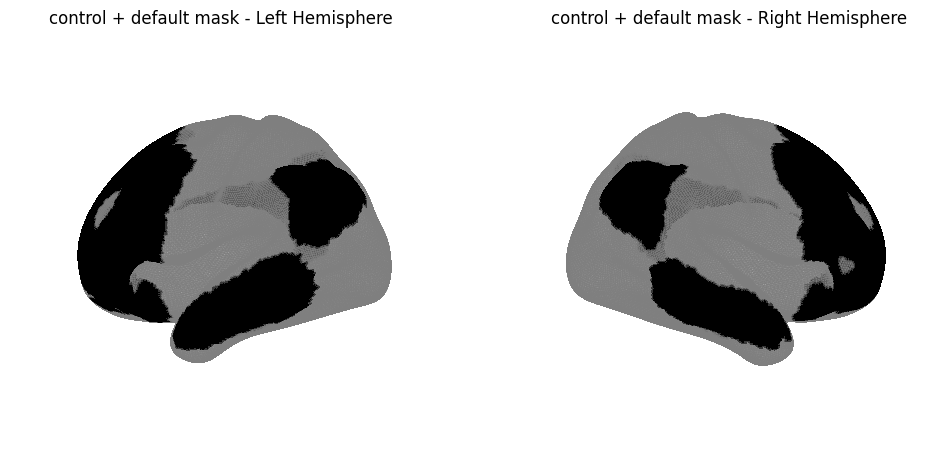

In [41]:
# yeo_parcels_binary.shape
# yeo_reshaped = yeo_parcels_binary[np.newaxis, :]  # Reshape to (1, 59518)

# # Convert to CIFTI format
# cifti = atlas.data_to_cifti(yeo_reshaped)

# # # Extract the data for the cortical surfaces
# all_img = nt.surf_from_cifti(cifti)

# # Plot cortical maps for left and right hemispheres
# fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
# for h, hemi in enumerate(['left', 'right']):
#     plotting.plot_surf_stat_map(
#         surfs[h], all_img[h], hemi=hemi,
#         colorbar=False,
#         cmap='binary',
#         axes=axes[h],
#         vmax=cscale_cortex[1],
#         threshold = 0.1,
#         title=f"control + default mask - {hemi.capitalize()} Hemisphere"
    )

In [20]:
comb = [7,10,0,32,36,33,30,35,34,22,27,31]
# comb =[1,2,3,4,5,6,7,8,9,10,11,12]

In [21]:
combination_data = combined_data_v2[np.array(comb), :]
combination_data_centered = combination_data - np.mean(combination_data, axis=1, keepdims=True)
cov_matrix = np.cov(combination_data_centered)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [22]:
print(eigenvalues)

[0.03882545 0.02933847 0.01504386 0.01055898 0.00998807 0.00664883
 0.00420892 0.00401688 0.00314206 0.00171463 0.00116256 0.00132645]


Text(0.5, 1.0, 'Eigenvalues from Covariance Matrix')

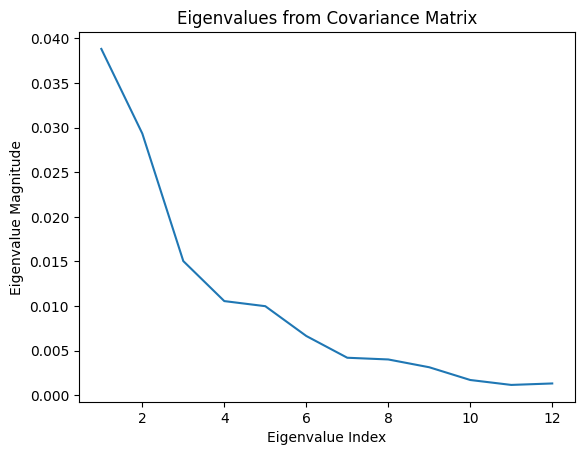

In [23]:
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues)
# Set labels and title
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue Magnitude')
plt.title('Eigenvalues from Covariance Matrix')

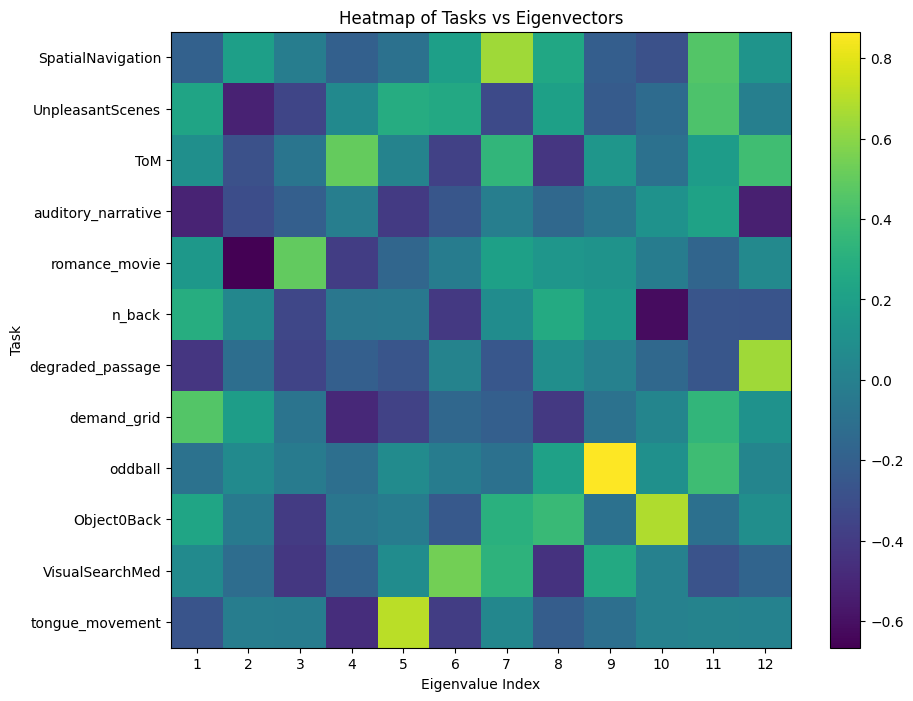

In [57]:
eigenvectors_matrix = eigenvectors  # Your (12, 12) eigenvector matrix

# Assuming you have a list of task names corresponding to each task index
task_labels = [task_names[index] for index in comb]  # Replace comb with your selected combination if necessary

# Plot the heatmap using imshow
plt.figure(figsize=(10, 8))
plt.imshow(eigenvectors_matrix, aspect='auto', cmap='viridis')

# Set the colorbar
plt.colorbar()

# Set the tick labels
plt.xticks(ticks=np.arange(eigenvectors_matrix.shape[1]), labels=np.arange(1, eigenvectors_matrix.shape[1] + 1))
plt.yticks(ticks=np.arange(eigenvectors_matrix.shape[0]), labels=task_labels)

# Set the labels for axes
plt.xlabel('Eigenvalue Index')
plt.ylabel('Task')
plt.title('Heatmap of Tasks vs Eigenvectors')

# Show the plot
plt.show()
